<a href="https://colab.research.google.com/github/lrrod/mackprojetoIV/blob/main/cd_projeto_aplicado_IV_doc_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/02**


# **Documentação do Projeto**

---

# **Título do Projeto**

**Previsão do consumo de energia elétrica da Região Sudeste do Brasil com variáveis climáticas e de atividade industrial: um produto analítico para o planejamento energético de cidades sustentáveis (ODS 11)**

---

In [ ]:
#@title **Identificação do Grupo**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Aluno 1, 123456789' #@param {type:"string"}
Aluno2 = 'Aluno 2, 123456789' #@param {type:"string"}
Aluno3 = 'Aluno 3, 123456789' #@param {type:"string"}
Aluno4 = 'Aluno 4, 123456789' #@param {type:"string"}
Aluno5 = 'Aluno 5, 123456789' #@param {type:"string"}


# **Resumo**

*(A ser redigido nas etapas finais — um parágrafo no modelo de resumo de artigo, indicando o problema, sua relevância, a metodologia aplicada e o principal resultado alcançado.)*

# **Introdução**

A energia elétrica é o insumo que sustenta o funcionamento das cidades contemporâneas: dela dependem os domicílios, o comércio, os serviços públicos, os sistemas de transporte e o parque industrial. No Brasil, a Região Sudeste concentra a maior parcela da demanda nacional — cerca de 21,5 mil GWh mensais, aproximadamente metade do consumo do país (BANCO CENTRAL DO BRASIL, 2026) — e abriga as maiores regiões metropolitanas do território nacional. Prever o comportamento futuro dessa demanda é tarefa central do planejamento energético: subestimá-la expõe a população a riscos de desabastecimento e racionamento, enquanto superestimá-la gera investimentos ociosos e pressão tarifária. O tema ganhou atualidade com a intensificação das ondas de calor, que elevam a demanda por climatização e têm produzido recordes sucessivos de carga no sistema elétrico brasileiro (EMPRESA DE PESQUISA ENERGÉTICA, 2026), e conecta-se diretamente ao Objetivo de Desenvolvimento Sustentável 11 — Cidades e Comunidades Sustentáveis — da Agenda 2030, na medida em que o suprimento confiável e eficiente de energia é condição para cidades resilientes (ORGANIZAÇÃO DAS NAÇÕES UNIDAS, 2015).

A motivação deste projeto nasce de uma característica bem documentada, porém nem sempre incorporada aos exercícios de previsão, do consumo de eletricidade: ele não é explicado apenas pelo seu próprio histórico. Duas forças externas exercem influência relevante sobre a série: a temperatura, que impulsiona o consumo residencial e comercial por meio de refrigeração e climatização, e o nível de atividade industrial, que responde por parcela expressiva da demanda total. Modelos puramente univariados ignoram essas relações — lacuna metodológica que abre a oportunidade concreta de ganho de desempenho preditivo pela incorporação de variáveis exógenas, abordagem recomendada pela literatura de previsão de séries temporais (HYNDMAN; ATHANASOPOULOS, 2021). Em análise preliminar da base construída para este projeto, a correlação entre as variações interanuais do consumo e da produção industrial paulista foi de 0,71, e a correlação entre as anomalias sazonais de consumo e de temperatura foi de 0,54 — evidências de que as variáveis explicativas escolhidas carregam informação útil para a previsão.

O objetivo geral do projeto é desenvolver um produto analítico baseado em séries temporais para a previsão do consumo mensal de energia elétrica da Região Sudeste do Brasil, incorporando variáveis exógenas climáticas e de atividade industrial. Para alcançá-lo, definem-se os seguintes objetivos específicos: (i) construir, por meio de coleta automatizada em APIs públicas oficiais, uma base de dados multivariada integrada, com granularidade mensal e período superior a duas décadas; (ii) realizar a análise exploratória e a decomposição da série de consumo, caracterizando tendência, sazonalidade, ciclos e resíduos; (iii) levantar e comparar técnicas de previsão — estatísticas, como os modelos da família ARIMA (BOX et al., 2015), e baseadas em aprendizado de máquina, como redes LSTM (HOCHREITER; SCHMIDHUBER, 1997) e o Prophet (TAYLOR; LETHAM, 2018); (iv) implementar ao menos um modelo univariado de referência (baseline SARIMA) e um modelo multivariado com variáveis exógenas (SARIMAX), avaliando-os por métricas de erro (MAPE, RMSE, MAE) sobre um conjunto de teste reservado ao final da série; e (v) traduzir os resultados em insights acionáveis para o planejamento energético.

A solução proposta configura um produto analítico completo e de viabilidade já demonstrada: um pipeline automatizado que coleta os dados diretamente das APIs oficiais a cada nova divulgação mensal — dispensando arquivos estáticos e mantendo o produto continuamente atualizado —, seguido das etapas de tratamento, treinamento, validação e geração de previsões com intervalos de confiança. A coleta e a integração das três fontes já foram implementadas e executadas com sucesso (seção de EDA e Pré-processamento), o que elimina o principal risco técnico do projeto. Como evolução, a arquitetura prevê a ingestão dos dados de carga horária disponibilizados em tempo quase real pelo Operador Nacional do Sistema Elétrico (2026), aproximando o produto de um cenário de processamento de dados em streaming.

O projeto justifica-se por suas contribuições em duas frentes. Do ponto de vista científico e metodológico, oferece um estudo de caso aberto e reprodutível — dados e código públicos, em consonância com o caráter extensionista da disciplina — sobre o ganho de desempenho obtido ao se incorporar variáveis exógenas à previsão de consumo de energia, comparando abordagens estatísticas clássicas e alternativas modernas sobre dados brasileiros. Do ponto de vista social, um modelo preditivo de demanda elétrica com bom desempenho fornece subsídios ao poder público, às distribuidoras e aos agentes do setor para antecipar picos de consumo, dimensionar a oferta e planejar a expansão da infraestrutura urbana, beneficiando diretamente os mais de 89 milhões de habitantes da região mais populosa do país.

**Descrição da base de dados.** A base do projeto é **multivariada**, com **granularidade mensal**, organizada em formato longitudinal (uma linha por mês, indexada pela data) e construída pela integração — junção pela chave ano-mês — de três fontes públicas oficiais, todas acessadas por APIs gratuitas e de coleta reprodutível em código:

| # | Variável | Fonte | Forma de acesso | Período na fonte | Registros |
|---|----------|-------|-----------------|------------------|-----------|
| 1 | Consumo de energia elétrica — Região Sudeste (GWh) — **variável-alvo** | Eletrobras, via SGS/Banco Central do Brasil, série 1431 | API REST (JSON) | fev/1979 – jun/2026 | 569 |
| 2 | Produção física industrial — SP (índice, base 2022 = 100) — exógena | PIM-PF/IBGE, tabela 8888 da API SIDRA | API REST (JSON) | jan/2002 – jun/2026 | 294 |
| 3 | Temperatura média mensal do ar a 2 m — São Paulo (°C) — exógena | NASA POWER (ponto 23,55° S, 46,63° O) | API REST (JSON) | jan/2002 – dez/2025 | 288 |

Após a integração, a base final cobre o período de **janeiro de 2002 a dezembro de 2025**, totalizando **288 registros mensais completos, sem valores faltantes**, com quatro atributos: tempo (mês), consumo (alvo), produção industrial e temperatura (exógenas). A série-alvo dispõe ainda de recortes setoriais (residencial, comercial e industrial) e regionais no SGS (BANCO CENTRAL DO BRASIL, 2026), que poderão ser explorados nas etapas seguintes; a produção industrial é medida pelo IBGE (2026) e a temperatura pelo projeto NASA POWER (NASA, 2026) — adotado como fonte climática principal pela estabilidade de acesso via API, tendo as séries de estação do INMET/BDMEP como fonte oficial brasileira alternativa. A originalidade da base está justamente na integração: não se trata de um conjunto pronto obtido de repositórios de competição, mas de uma composição própria de três fontes primárias, com coleta automatizada que se atualiza a cada divulgação mensal dos órgãos oficiais.

# **Referencial Teórico**

*(A ser desenvolvido na Etapa 2 — 1 página: principais conceitos da solução, trabalhos correlatos, alternativas de solução com vantagens e limitações, com referências em padrão ABNT.)*


# **Diagrama de Solução**

*(A ser desenvolvido na Etapa 2 — diagrama do pipeline: coleta via APIs → tratamento e integração → EDA/decomposição → treinamento (SARIMA baseline e SARIMAX com exógenas) → validação por métricas → previsões e insights.)*

# **EDA e Pré-processamento dos dados**

*(Análise exploratória completa a ser desenvolvida na Etapa 2.)* O código a seguir — antecipado da etapa de coleta — demonstra a viabilidade da solução: reproduz integralmente a obtenção das três fontes, a integração pela chave ano-mês e a verificação de integridade da base.

In [ ]:
import urllib.request, json, gzip
import pandas as pd
import matplotlib.pyplot as plt

def obter_json(url):
    """Requisição GET com suporte a gzip — todas as fontes são APIs públicas."""
    req = urllib.request.Request(url, headers={'Accept-Encoding': 'gzip', 'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=90) as r:
        raw = r.read()
    if raw[:2] == b'\x1f\x8b':
        raw = gzip.decompress(raw)
    return json.loads(raw.decode())

# ── Fonte 1: Consumo de energia elétrica — Região Sudeste (GWh) — SGS/BCB, série 1431 ──
consumo = pd.DataFrame(obter_json('https://api.bcb.gov.br/dados/serie/bcdata.sgs.1431/dados?formato=json'))
consumo['data'] = pd.to_datetime(consumo['data'], format='%d/%m/%Y')
consumo['consumo_gwh'] = pd.to_numeric(consumo['valor'])
consumo = consumo.set_index('data')[['consumo_gwh']].asfreq('MS')
print(f'Consumo Sudeste : {len(consumo)} registros | {consumo.index.min():%m/%Y} a {consumo.index.max():%m/%Y}')

# ── Fonte 2: Produção física industrial — SP — PIM-PF/IBGE (SIDRA t8888, v12606) ──
pim_raw = obter_json('https://apisidra.ibge.gov.br/values/t/8888/n3/35/v/12606/p/all/c544/129314?formato=json')[1:]
pim = pd.DataFrame({'data': pd.to_datetime([x['D3C'] for x in pim_raw], format='%Y%m'),
                    'pim_sp': pd.to_numeric([x['V'] for x in pim_raw])}).set_index('data').asfreq('MS')
print(f'PIM-PF SP       : {len(pim)} registros | {pim.index.min():%m/%Y} a {pim.index.max():%m/%Y}')

# ── Fonte 3: Temperatura média mensal — São Paulo — NASA POWER (T2M) ──
t2m = obter_json('https://power.larc.nasa.gov/api/temporal/monthly/point'
                 '?parameters=T2M&community=AG&longitude=-46.63&latitude=-23.55'
                 '&start=2002&end=2025&format=JSON')['properties']['parameter']['T2M']
t2m = {k: v for k, v in t2m.items() if not k.endswith('13')}  # descarta médias anuais (mês '13')
temperatura = pd.DataFrame({'data': pd.to_datetime(list(t2m.keys()), format='%Y%m'),
                            'temp_media_c': list(t2m.values())}).set_index('data').asfreq('MS')
print(f'Temperatura SP  : {len(temperatura)} registros | {temperatura.index.min():%m/%Y} a {temperatura.index.max():%m/%Y}')

# ── Integração (join pela chave ano-mês) e verificação de integridade ──
base = consumo.join([pim, temperatura], how='inner')
base.to_csv('base_integrada.csv')
print(f'\nBase integrada  : {base.shape[0]} registros x {base.shape[1]} variáveis '
      f'| {base.index.min():%m/%Y} a {base.index.max():%m/%Y}')
print(f'Valores faltantes: {int(base.isna().sum().sum())}')
base.describe().round(2)

Consumo Sudeste : 569 registros | 02/1979 a 06/2026


PIM-PF SP       : 294 registros | 01/2002 a 06/2026


Temperatura SP  : 288 registros | 01/2002 a 12/2025

Base integrada  : 288 registros x 3 variáveis | 01/2002 a 12/2025
Valores faltantes: 0


,consumo_gwh,pim_sp,temp_media_c
count,288.00,288.00,288.00
mean,18674.19,105.72,19.80
std,2505.82,14.14,2.58
min,12158.00,65.95,14.12
25%,17013.75,94.80,17.50
50%,19304.50,106.24,20.39
75%,20326.25,114.10,21.91
max,24173.00,140.91,24.93


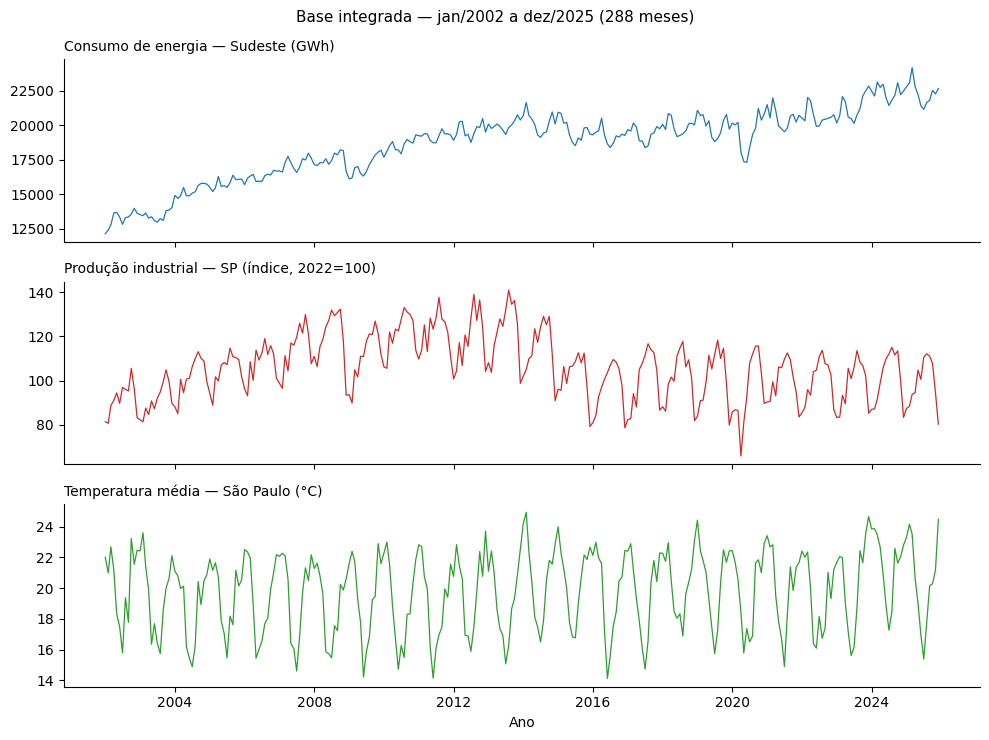

Correlação (variação interanual) consumo x produção industrial: 0.712
Correlação (anomalia sazonal)    consumo x temperatura:         0.543


In [ ]:
# ── Visualização das três séries e evidência preliminar das relações ──
fig, eixos = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True)
series = [('consumo_gwh', 'Consumo de energia — Sudeste (GWh)', '#1f77b4'),
          ('pim_sp', 'Produção industrial — SP (índice, 2022=100)', '#d62728'),
          ('temp_media_c', 'Temperatura média — São Paulo (°C)', '#2ca02c')]
for eixo, (col, titulo, cor) in zip(eixos, series):
    eixo.plot(base.index, base[col], color=cor, linewidth=0.9)
    eixo.set_title(titulo, fontsize=10, loc='left')
    eixo.spines[['top', 'right']].set_visible(False)
eixos[-1].set_xlabel('Ano')
fig.suptitle('Base integrada — jan/2002 a dez/2025 (288 meses)', fontsize=11)
fig.tight_layout()
plt.show()

dif12 = base.diff(12).dropna()          # variação interanual: remove a tendência
anomalia = base - base.groupby(base.index.year).transform('mean')  # anomalia: isola a sazonalidade
print('Correlação (variação interanual) consumo x produção industrial:',
      round(dif12['consumo_gwh'].corr(dif12['pim_sp']), 3))
print('Correlação (anomalia sazonal)    consumo x temperatura:        ',
      round(anomalia['consumo_gwh'].corr(anomalia['temp_media_c']), 3))

# **Modelos**

*(A ser desenvolvido na Etapa 3 — descrição metodológica da criação, refinamento e validação dos modelos: baseline univariado SARIMA e modelo principal SARIMAX com variáveis exógenas.)*

In [ ]:
# Códigos aqui

# **Resultados**

*(A ser desenvolvido na Etapa 3 — métricas MAPE, RMSE e MAE sobre o conjunto de teste; tabelas comparativas entre os modelos.)*

# **Dicussão e Conclusão**

*(A ser desenvolvido na Etapa 4 — conclusões, análise crítica, alcance do objetivo inicial e potenciais melhorias.)*

# **Apresentação**

*(A ser incluído na Etapa 4 — link do vídeo de apresentação, até 10 minutos, com apoio de slides.)*

# **Referências**

BANCO CENTRAL DO BRASIL. **Sistema Gerenciador de Séries Temporais (SGS)**: série 1431 — Consumo de energia elétrica — Região Sudeste (GWh), Eletrobras. Brasília, DF, 2026. Disponível em: https://www3.bcb.gov.br/sgspub. Acesso em: 30 ago. 2026.

BOX, G. E. P.; JENKINS, G. M.; REINSEL, G. C.; LJUNG, G. M. **Time series analysis**: forecasting and control. 5. ed. Hoboken: John Wiley & Sons, 2015.

EMPRESA DE PESQUISA ENERGÉTICA. **Resenha mensal do mercado de energia elétrica**. Rio de Janeiro: EPE, 2026. Disponível em: https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/consumo-de-energia-eletrica. Acesso em: 30 ago. 2026.

HOCHREITER, S.; SCHMIDHUBER, J. Long short-term memory. **Neural Computation**, v. 9, n. 8, p. 1735-1780, 1997.

HYNDMAN, R. J.; ATHANASOPOULOS, G. **Forecasting**: principles and practice. 3. ed. Melbourne: OTexts, 2021. Disponível em: https://otexts.com/fpp3/. Acesso em: 30 ago. 2026.

INSTITUTO BRASILEIRO DE GEOGRAFIA E ESTATÍSTICA (IBGE). **Pesquisa Industrial Mensal — Produção Física (PIM-PF)**: tabela 8888 — Produção física industrial, por seções e atividades industriais. Rio de Janeiro, 2026. Disponível em: https://sidra.ibge.gov.br/tabela/8888. Acesso em: 30 ago. 2026.

NASA. **POWER — Prediction Of Worldwide Energy Resources**: monthly temperature at 2 meters (T2M). Hampton: NASA Langley Research Center, 2026. Disponível em: https://power.larc.nasa.gov. Acesso em: 30 ago. 2026.

OPERADOR NACIONAL DO SISTEMA ELÉTRICO (ONS). **Portal de dados abertos**: carga verificada. Rio de Janeiro, 2026. Disponível em: https://dados.ons.org.br. Acesso em: 30 ago. 2026.

ORGANIZAÇÃO DAS NAÇÕES UNIDAS (ONU). **Transformando nosso mundo**: a Agenda 2030 para o Desenvolvimento Sustentável. Nova York: ONU, 2015. Disponível em: https://brasil.un.org/pt-br/91863. Acesso em: 30 ago. 2026.

TAYLOR, S. J.; LETHAM, B. Forecasting at scale. **The American Statistician**, v. 72, n. 1, p. 37-45, 2018.
